# Practice 1: Pytorch basics
- Task 1: Tensor basics
- Task 2: Optimization in PyTorch
- Task 2.1: Unconstrained optimization
- Task 2.2: Constrained optimization
- Task 3: Binary classification; Logistic Regression on MNIST
- Task 4: Multi-class classification

# Task 1: Tensors warm-up 
Not much different than numpy, but faster (can work on GPU)

In [1]:
# generate a random tensor
import torch
import numpy as np

# set the seed for reproducibility
torch.manual_seed(0)

# generate a random tensor
x = torch.rand(2, 3)
y = torch.rand(2, 3)
print("x:", x)
print("y:", y)

# move the tensor to the GPU ("mps", "cuda", "cuda:0", "cuda:1", etc.)
x = x.to("mps")
y = y.to("mps")

# get the shape of the tensor
print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

# transpose the tensor
print ("transpose of x:", x.t())

# add the tensors
z = x + y
print("Sum of x and y:", z)

# element-wise multiplication
# TODO
z = x * y

# element-wise division
z = x / y

# random vector
v = torch.rand(3)

# matrix-vector multiplication
print ("x @ v:", x @ v.to("mps"))

x: tensor([[0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, 0.6341]])
y: tensor([[0.4901, 0.8964, 0.4556],
        [0.6323, 0.3489, 0.4017]])
Shape of x: torch.Size([2, 3])
Shape of y: torch.Size([2, 3])
transpose of x: tensor([[0.4963, 0.1320],
        [0.7682, 0.3074],
        [0.0885, 0.6341]], device='mps:0')
Sum of x and y: tensor([[0.9863, 1.6647, 0.5441],
        [0.7643, 0.6563, 1.0358]], device='mps:0')
x @ v: tensor([0.1668, 0.2412], device='mps:0')


torch.Size([3, 256, 256])


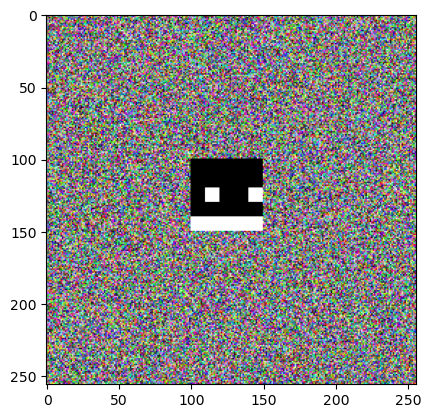

In [2]:
# generate a random image (256x256x3) -> (height x width x channels)
image = torch.rand(256, 256, 3)

# swap the axes: (height x width x channels) -> (channels x height x width)
import einops
# TODO
print (einops.rearrange(image, 'h w c -> c h w').shape)

# draw the image
import matplotlib.pyplot as plt

# draw a smiley face
image[100:150, 100:150, :] = 0
image[120:130, 110:120, :] = 1
image[120:130, 140:150, :] = 1
image[140:150, 100:150, :] = 1
image[140:150, 100:110, :] = 1
image[140:150, 140:150, :] = 1

# draw the image
plt.imshow(image)
plt.show()
 

# Task 2: Optimization in Pytorch

# Gradient descent:
Gradient descent is an optimization algorithm that iteratively updates parameters in the direction of the negative gradient to minimize a function.
Gradient descent updates the variable  $x$ by moving in the opposite direction of the gradient:
$$x_{t+1} = x_t - \eta \nabla f(x_t)$$
where $\eta$  is the learning rate.

## Why does it work?
We show that $f(x_{t+1}) \leq f(x_t)$ using the above update step, which means that we get progressively closer to the minimum of $f$ (if $f$ is convex).

For a differentiable function $f(x)$, we can approximate it around a point $x_t$ using a first-order Taylor expansion:
$$f(x) \approx f(x_t) + \nabla f(x_t)^\top (x - x_t) + \mathcal{O}(\|x - x_t\|^2)$$
Ignoring higher-order terms, this shows that $f(x)$  behaves approximately like a **linear function** near $x_t$, and its 1st-order Taylor expansion provides its **best** local linear approximation.

Using the first-order Taylor approximation:
$f(x_{t+1}) \approx f(x_t) + \nabla f(x_t)^\top (x_{t+1} - x_t)$

Substituting  $x_{t+1} = x_t - \eta \nabla f(x_t)$, we get:
$$f(x_{t+1}) \approx f(x_t) - \eta \|\nabla f(x_t)\|^2$$
Since  $\|\nabla f(x_t)\|^2 \geq 0$, this shows that for small enough  $\eta$, the function value decreases at each step, ensuring progress toward a minimum.

**Sidenote**: A second-order Taylor expansion provides a more refined approximation:
$f(x) \approx f(x_t) + \nabla f(x_t)^\top (x - x_t) + \frac{1}{2} (x - x_t)^\top H(x_t) (x - x_t)$
where  $H(x_t)$  is the Hessian matrix. If  $H(x_t)$  is positive definite, it gives information about the curvature, helping adjust the step size dynamically. 
(In gradient descent, updates follow only the gradient  $\nabla f(x)$, but this can lead to slow progress in regions with high curvature.)
This leads to Newton’s method, which uses:
$x_{t+1} = x_t - H(x_t)^{-1} \nabla f(x_t)$
where the Hessian provides a second-order correction.
Therefore, using second derivatives (Hessian matrix) can speed up convergence because it provides curvature information, allowing for more precise updates.
However, computing the Hessian is expensive compared to just using gradients, both in terms of time and memory. 
In high-dimensional problems (e.g., deep learning with many model parameters), computing the Hessian explicitly is too costly, so we often rely on gradient-based methods like Adam or momentum-based optimization. In smaller-scale convex optimization, Newton’s method can be useful for rapid convergence.


## Task 2.1: Unconstrained optimization

In [3]:
import torch 

# Solve a simple optimization problem
# f(x_1,y_@) = (x_1 - 2)^2 + (x_2 - 3)^2
# the minimum is at x = 2, y = 3

# first manual gardient descent
# starting point: x is two-dimensional tensor
# TODO
x = torch.tensor([0.0, 0.0], requires_grad=True)
f = lambda x: (x[0] - 2)**2  + (x[1]-3)**2
# TODO
eta = 0.01

# learning rate
# TODO
n_iterations = 1000
# number of iterations
# TODO

for i in range(n_iterations):

    # compute the function (foward pass)
    # TODO
    val = f(x)

    # compute the gradient (backward pass)
    # compute gradient of the loss with respect to all the learnable
    # parameters of the model. Internally, the parameters of each Module are stored
    # in Tensors with requires_grad=True, so this call will compute gradients for
    # all learnable parameters in the model.
    # TODO
    val.backward()

    # Update the weights using gradient descent. Each parameter is a Tensor,
    # TODO
    with torch.no_grad():
        x -= eta * x.grad

    # zero the gradient
    # TODO
    x.grad.zero_()
print("x_min:", x)
print ("f(x_min):", f(x))


x_min: tensor([2.0000, 3.0000], requires_grad=True)
f(x_min): tensor(4.0927e-11, grad_fn=<AddBackward0>)


Now with built-in optimizer:

In [4]:
# now with the optimizer
# starting point: x is two-dimensional tensor
x = torch.tensor([0.0, 0.0], requires_grad=True)

# optimizer
# TODO
optimizer = torch.optim.SGD([x], lr=eta)

for i in range(n_iterations):
    
    # compute the function (forward pass)
    val = f(x)
   
    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # compute the gradient
    val.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    # TODO
    optimizer.step()
    
print("x_min:", x)
print ("f(x_min):", f(x))

x_min: tensor([2.0000, 3.0000], requires_grad=True)
f(x_min): tensor(4.4409e-11, grad_fn=<AddBackward0>)


/Users/acs/miniforge3/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1770196967836/work/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


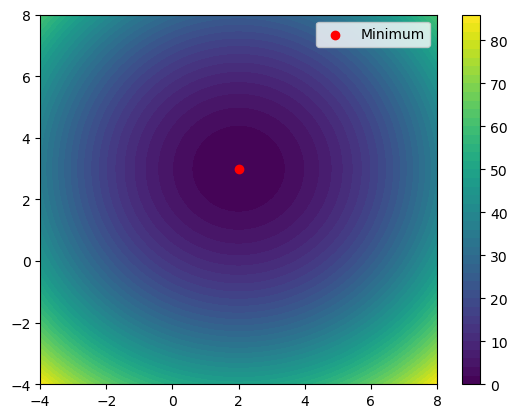

In [5]:
import matplotlib.pyplot as plt

x1 = torch.linspace(-4, 8, 100)
x2 = torch.linspace(-4, 8, 100)
X1, X2 = torch.meshgrid(x1, x2)
Z = (X1 - 2)**2 + (X2 - 3)**2
plt.contourf(X1, X2, Z, levels=50)
plt.colorbar()
plt.scatter(x[0].item(), x[1].item(), color='red', label='Minimum')
plt.legend()
plt.show()


## Task 2.2: Constrained Optimization

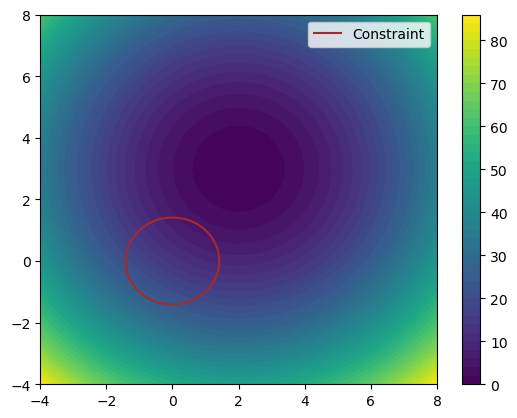

In [7]:
# now add constraints
# f(x_1,y_2) = (x_1 - 2)^2 + (x_2 - 3)^2
# subject to x_1^2 + x_2^2 = 2

# plot the function with the constraint
x1 = torch.linspace(-4, 8, 100)
x2 = torch.linspace(-4, 8, 100)
X1, X2 = torch.meshgrid(x1, x2)
Z = (X1 - 2)**2 + (X2 - 3)**2
plt.contourf(X1, X2, Z, levels=50)
plt.colorbar()
# plot the constraint
theta = np.linspace(0, 2 * np.pi, 100)
x1_con = np.sqrt(2) * np.cos(theta)
x2_con = np.sqrt(2) * np.sin(theta)
plt.plot(x1_con, x2_con, color='brown', label='Constraint')

plt.legend()
plt.show()


### Converting constrained to unconstrained optimization

As we'll see in subsequent lectures, an (adaptive) attacker often have constraints, e.g., it needs to bypass a defense, which is a constraint, or it cannot modify all features to evade a model, which can be another constraint. However, pytorch cannot solve constrained problems, so we need to convert any constrained problem into an unconstrained with a method based on Lagrange multipliers.

For illustration, suppose we want to minimize $f(x)$ subject to $g(x) = 0$.
The idea that $\nabla g$ and $\nabla f$ must be parallel for any local minimum on the surface of $g(x)$. In that case, 
$$
\nabla f = \mu \cdot \nabla g
$$
where $\mu$ is the lagrange multiplier.
Hence,  
$$
\nabla f - \mu \cdot \nabla g = 0 
$$
Therefore, if 
$$
\mathcal{L}(x, \mu) = f(x) - \mu \cdot g(x)
$$
then solving $\nabla_{x, \mu} \mathcal{L}(x,\mu) = 0$ will provide the local minimas (or maximas) given the constraint $g$, where $\mathcal{L}(x, \mu)$ is also called the Lagrangian of the original constrained optimization problem. 
We can transform the constrained optimization into an unconstrained optimization by fixing $\mu$ and minimizing the Lagrangian
$$
\mathcal{L}(x, \mu) = f(x) - \mu \cdot g(x)
$$
with respect to $x$. The choice of $\mu$ depends on what we want more; minimizing $f(x)$ or satisfying the constraint $g(x)=0$. Hence $\mu$ acts as a trade-off parameter between these two objectives.

Why are $\nabla g$ and $\nabla f$ parallel? 
First, we show that $\nabla g$ is perpendicular to the constrained surface $g(x)=0$.
For any function $g$, the directional derivative in direction $v$ is $\nabla g \cdot v$. This tells you how fast $g$ changes if you walk in direction $v$. The gradient $\nabla g$ points in the direction that maximizes this rate of change. Now consider the constraint surface $g(x) = 0$. If you walk along this surface (i.e., you stay on it), then by definition $g$ doesn't change at all. So the directional derivative of $g$ along any direction tangent to the surface is zero: $\nabla g \cdot v = 0$ for every tangent direction $v$ $\implies$ If $\nabla g$ has zero dot product with every vector lying in the surface, then $\nabla g$ must be perpendicular to the surface.  
Second, we show that $\nabla f$ and $\nabla g$ are parallel. Suppose that they are not parallel, but we are still at local minimum (or maximum). Then $\nabla f$ has some component that lies within the constraint surface, i.e., there's a direction $v$ that is both:
1. perpendicular to $\nabla g$ (so it stays on the constraint surface), and
2. has a positive dot product with $\nabla f$ (so it increases $f$). 

You can always find such a $v$ when $\nabla f$ isn't parallel to $\nabla g$ — just take the projection of $\nabla f$ onto the constraint surface. If $\nabla f$ isn't already perpendicular to the surface, that projection is nonzero and points "uphill" along the surface. So you could move in direction $v$, stay on $g = 0$, and increase $f$, meaning you weren't at a constrained maximum after all. This is a contradiction.


### Constrained Optimization in Pytorch

We solve the following constrained problem: $\min_{x_1, x_2} (x_1 - 2)^2 + (x_2 - 3)^2$ given the constraint that $x_1^2 + x_2^2 = 2$ by converting into an unconstrained (Lagrangian) form: 
$$
\mathcal{L}(x_1,x_2, \mu) = (x_1 - 2)^2 + (x_2 - 3)^2 - \mu \cdot (x_1^2 + x_2^2 - 2)
$$
and then solving 
$$
\nabla_{x_1, x_2, \mu} \mathcal{L}(x,y, \mu) =0
$$
(3 equations with 3 unknowns)
We obtain (homework):
$$
x_1^{min} \approx 0.784, x_2^{min} \approx 1.176
$$

In what follows, we approximate this solution by computing the minimum of $\mathcal{L}(x_1,x_2, \mu)$ with gradient descent. This shows that even if we cannot compute the Lagrange multiplier analytically (e.g., for non-convex neural nets), we can approximate the trade-off by gradient descent where we empirically adjust the trade-off parameter (or multiplier) $\mu$.

x_min: tensor([0.6667, 1.0000], requires_grad=True)
f(x_min): tensor(5.7778, grad_fn=<AddBackward0>)


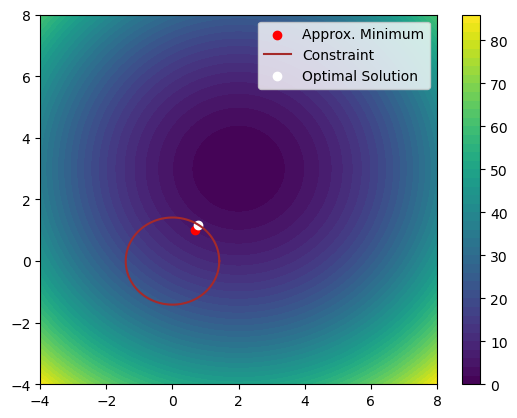

In [13]:
# now with the optimizer
x = torch.tensor([0.0, 0.0], requires_grad=True)

# optimizer
optimizer = torch.optim.SGD([x], lr=eta)

# add the constraint as a penalty term
# TODO
g = lambda x: (x[0]**2 + x[1]**2 - 2)
mu = 2
# TODO

L = lambda x: f(x) + mu * g(x)
# TODO

for i in range(n_iterations):
    
    # compute the function (forward pass)
    # TODO
    val = L(x)
   
    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # compute the gradient
    val.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step()
    
print("x_min:", x)
print ("f(x_min):", f(x))

# plot the function
Z = (X1 - 2)**2 + (X2 - 3)**2
plt.contourf(X1, X2, Z, levels=50)
plt.colorbar()
plt.scatter(x[0].item(), x[1].item(), color='red', label='Approx. Minimum')
# plot the constraint
theta = np.linspace(0, 2 * np.pi, 100)
x1_con = np.sqrt(2) * np.cos(theta)
x2_con = np.sqrt(2) * np.sin(theta)
plt.plot(x1_con, x2_con, color='brown', label='Constraint')

# computed analytically with Lagrange multipliers
x1_opt = 0.784
x2_opt = 1.176
plt.scatter(x1_opt, x2_opt, color='white', label='Optimal Solution')

plt.legend()
plt.show()

# Task 4: MNIST

We first build a logistic regression model to distinguish handwritten '5' from handwritten '0'. It is a binary classification task 

## Step 1: Load data

In [14]:
import torch
from torchvision import datasets, transforms


In [15]:
train_dataset = datasets.MNIST(root='./data', 
                            train=True, 
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = datasets.MNIST(root='./data', 
                           train=False, 
                           transform=transforms.ToTensor())



Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

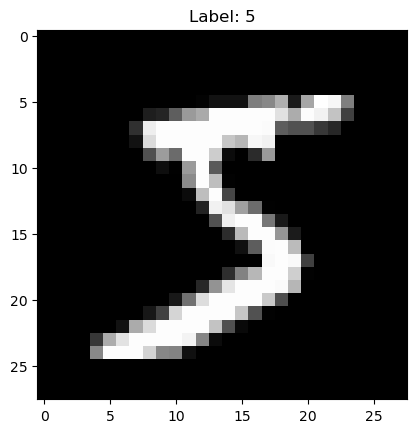

In [16]:
# What is it?
print (train_dataset)
print (test_dataset)
# tuple: (image, label)
print(train_dataset[0])
# image dimensions: (batch, channel, height, width). Channel is 1 because it's grayscale
print("Image dimension:", train_dataset[0][0].shape)
# label
print("Label:", train_dataset[0][1])

# let's display the image
import matplotlib.pyplot as plt

# plot in greyscale
plt.imshow(train_dataset[0][0].squeeze(), cmap='gray')

# set title to the label
plt.title(f"Label: {train_dataset[0][1]}")
plt.show()


Train dataset size: 11344
Test dataset size: 1872


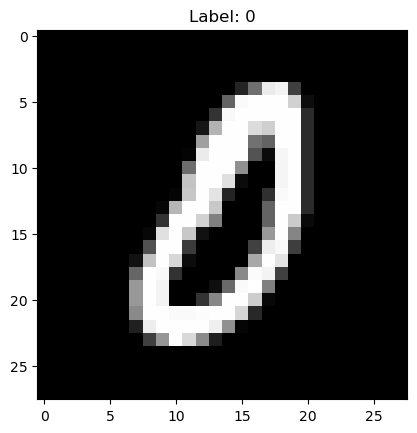

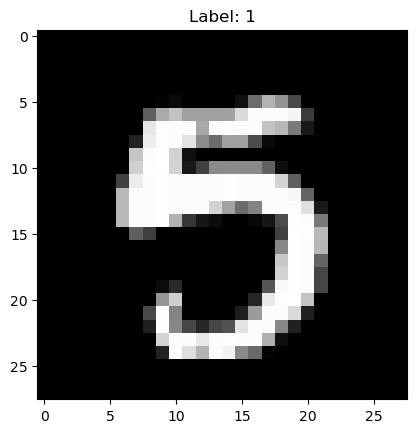

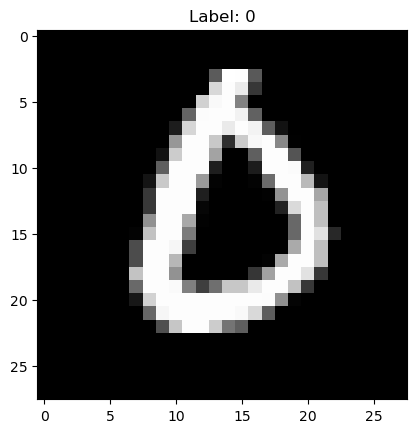

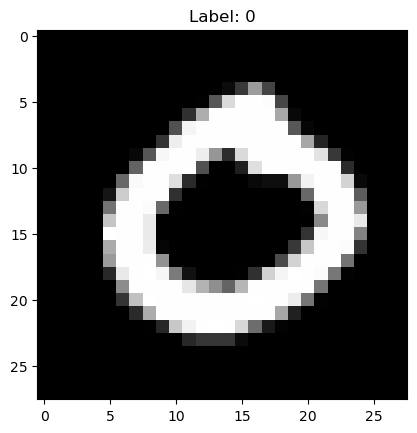

In [17]:
import numpy as np

def create_dataset(dataset):
    # get all the images and labels
    images = dataset.data
    labels = dataset.targets

    # get the images
    images_0 = images[labels == 0]
    images_5 = images[labels == 5]

    # binary labels
    images = torch.cat((images_0, images_5))
    # 0 -> label: 0, 5 -> label: 1
    labels = torch.cat((torch.zeros(images_0.shape[0]).long(), torch.ones(images_5.shape[0]).long()))

    # create tensor dataset
    return torch.utils.data.TensorDataset(images, labels)

traindata = create_dataset(train_dataset)
testdata = create_dataset(test_dataset)
# TODO

print("Train dataset size:", len(traindata))
print("Test dataset size:", len(testdata))

# 4 random samples
indices = np.random.randint(0, len(traindata), 4)
for i in indices:
    plt.imshow(traindata[i][0], cmap='gray')
    plt.title(f"Label: {traindata[i][1]}")
    plt.show()



## Step 2: Create model

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()
        # TODO
        self.linear = nn.Linear(input_dim, output_dim)
    
    # Output: logit (sigmoid is applied by the loss function)
    def forward(self, x):
        out = self.linear(x)
        return out
        # TODO
        # TODO


In [33]:
input_dim = 28 * 28
output_dim = 1 # binary classification: output is a single scalar

# TODO
model = LogisticRegressionModel(input_dim, output_dim)

## Step 3: Define optimizer, learning rate, dataloaders

We compare the predictions of the model with the actual labels $y$ using the loss function
$loss(f(x | \theta), y)$, which measures the prediction error, where $f(x | \theta)$ denotes the model output on input $x$. The model has parameters $\theta$.
We want to minimize the loss function (the prediction error) by adjusting the parameters $\theta$ of the model. For this purpose, we use gradient descent to minimize the average prediction error, where the average is taken over the training samples:
\begin{align}
\theta_{t+1} &= \theta_{t} - \eta \cdot \nabla_{\theta}\frac{1}{|D_{tr}|}\sum_{(x,y)\in D_{tr}}loss(f(x | \theta), y) \\
 &= \theta_{t} - \eta \cdot \frac{1}{|D_{tr}|}\sum_{(x,y)\in D_{tr}}\nabla_{\theta}loss(f(x | \theta), y) 
\end{align}
where $D_{tr}$ is the training data, and $loss$ should be any differentiable error function (e.g., mean squared error (MSE) for regression, and cross-entropy for classification). This says that we have to compute the average gradient over the entire training data in each step. This would be quite expensive. Stochastic Gradient Descent (SGD) rather approximates the average gradient by sampling (at the cost of minor accuracy degradation):

\begin{align}
\theta_{t+1} &= \theta_{t} - \eta \cdot \frac{1}{|D_{tr}|}\sum_{(x,y)\in D_{tr}} \nabla_{\theta}loss(f(x | \theta), y) \\
&= \theta_{t} - \eta \cdot \mathbb{E}_{(x,y)\sim D_{tr}} [\nabla_{\theta}loss(f(x | \theta), y)]\\
&\approx \theta_{t} - \eta \cdot \frac{1}{|B|}\sum_{(x,y) \in B | B\sim D_{tr}} [\nabla_{\theta}loss(f(x | \theta), y)]
\end{align}
where the expected value is approximated by sampling: a random mini-batch $B$ of samples is chosen ($|B| \ll |D_{tr}|$) instead of the whole training set $D_{tr}$, and the expected value is estimated by the average gradient of this mini-batch.

For a training sample with digit 0, our model should output 0, and for digit 5, it should output label 1. However, our linear model outputs a real value between $-\infty$ and $\infty$. Logistic regression applies a sigmoid function $\frac{1}{1+e^{-x}}$ to transform this value into a probability value between 0 and 1. This probability should be close to 1 if the input is a digit of 5, and close to 0 otherwise. Therefore, we need a loss function that compares two probability distributions.
One way is the cross-entropy: 
$$
loss(f(x | \theta), y) = -y \log (\mathsf{sigmoid}(f(x | \theta))) -(1-y)\log(1 - \mathsf{sigmoid}(f(x | \theta)))
$$
If the model prediction and the ground truth label agrees, the cross-entropy is 0.
The Binary Cross-Entropy is implemented by BCEWithLogitsLoss which expects the ground truth label as binary value 0/1, and the model output as a logit value (and not probability value). BCEWithLogitsLoss applies sigmoid on the model output (logit value) before computing the cross entropy.

In [34]:
# loss function
# TODO
criterion = nn.BCEWithLogitsLoss()

learning_rate = 0.001

# TODO
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Data loaders to iterate over the dataset
# TODO
train_loader = torch.utils.data.DataLoader(traindata, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(testdata, batch_size=64)
# TODO

## Step 4: Training loop

In [35]:
from tqdm import tqdm
import einops

print ("Train loader size:", len(train_loader))
print ("Test loader size:", len(test_loader))

def train_epoch(model, device, train_loader, optimizer):
    model.train()
    # one epoch is one pass through the dataset
    for data, target in tqdm(train_loader):
        # send the data to the device (GPU or CPU)
        data, target = data.float().to(device), target.to(device).float()

        # reshape the data 28x28 -> 784
        data = einops.rearrange(data, 'b h w -> b (h w)')
        # reshape the target batch -> (batch_size, 1)
        target = einops.rearrange(target, 'b -> b 1')
      
        # zero the gradients
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        # TODO
        output = model(data)

        # calculate the loss (negative log likelihood loss -> prediction error)
        # TODO
        loss = criterion(output, target)

        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (model parameter update)
        optimizer.step()

def test(model, device, test_loader):
    # set the model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    # turn off computation of gradients
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device).float(), target.to(device).float()
          
            # reshape the data 28x28 -> 784
            data = einops.rearrange(data, 'b h w -> b (h w)')
            # reshape the target batch -> (batch_size, 1)
            target = einops.rearrange(target, 'b -> b 1')
            
            # TODO 
            output = model(data) 
          
            test_loss += criterion(output, target).item()  # sum up batch loss
            
            # logit -> sigmoid -> decision
            # TODO
            # TODO
            output = torch.sigmoid(output)
            output = (output > 0.5).float()

            correct += (output == target).sum().item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset)}%)\n')

# train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

n_epochs = 10
for epoch in range(n_epochs):
    train_epoch(model, device, train_loader, optimizer)
    test(model, device, test_loader)



Train loader size: 178
Test loader size: 30


100%|██████████| 178/178 [00:00<00:00, 1155.07it/s]



Test set: Average loss: 0.0170541478167227, Accuracy: 1849/1872 (98.77136752136752%)



100%|██████████| 178/178 [00:00<00:00, 1600.62it/s]



Test set: Average loss: 0.010460751696338552, Accuracy: 1854/1872 (99.03846153846153%)



...


Test set: Average loss: 0.6132671329805739, Accuracy: 1227/1872 (65.5448717948718%)



100%|██████████| 178/178 [00:00<00:00, 1544.08it/s]



Test set: Average loss: 0.015539870067855751, Accuracy: 1850/1872 (98.82478632478633%)



100%|██████████| 178/178 [00:00<00:00, 1544.40it/s]


Test set: Average loss: 0.011806359084752896, Accuracy: 1852/1872 (98.93162393162393%)



# Task 3.2: Multiclass classification (distinguish 10 digits)

In [36]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

# Task 3.3: Training loop

In [37]:
# Data loaders to iterate over the dataset
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [38]:
from tqdm import tqdm
import torch
import torch.nn.functional as F

def train_epoch(model, device, train_loader, optimizer):
    model.train()
    # one epoch is one pass through the dataset
    for data, target in tqdm(train_loader):
        # send the data to the device (GPU or CPU)
        data, target = data.to(device), target.to(device)
        # zero the gradients
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the loss (negative log likelihood loss -> prediction error)
        loss = F.nll_loss(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (model parameter update)
        optimizer.step()
        
      

# Task 3.4: Testing loop

In [39]:
from einops import rearrange

def test(model, device, test_loader):
    # set the model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    # turn off computation of gradients
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            # print output shape, wait for pressed key
            ##print("Output shape:", output.shape, "output:", output)
            # target: ground truth digit that should be predicted (batch_size)
            ##print ("Target shape:", target.shape, "target:", target)
            ##input()
            # output: logit values (and not probabilities) with shape (batch_size, num_classes)
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            # pred: max logit value (batch_size, 1)
            ##print("Pred shape:", output.shape, "pred:", pred)
            ##input()
            # Option 1: rearrange the tensor to the same shape as the target tensor
            correct += (rearrange(pred, 'b 1 -> b') == target).sum().item()
            # Option 2: view_as: view this tensor as the same size as the target tensor
            # correct += pred.eq(target.view_as(pred)).sum().item()
            # Option 3: flatten the tensor
            # correct += pred.flatten().eq(target).sum().item()
            # Option 4: squeeze the tensor
            # correct += pred.squeeze().eq(target).sum().item()
            # Option 5: convert to numpy
            # correct += pred.numpy().flatten() == target.numpy().flatten()

    test_loss /= len(test_loader.dataset)

    print(f'\nTest set: Average loss: {test_loss}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset)}%)\n')


In [40]:
# Train
EPOCHS = 10

device = torch.device("mps") # fro apple silicon, "cpu" for normal cpu, "cuda" for nvidia

# create model
model = Net().to(device)
# create optimizer and scheduler to update model parameters
optimizer = optim.Adadelta(model.parameters(), lr=0.001)

for epoch in range(1, EPOCHS + 1):
    train_epoch(model, device, train_loader, optimizer)
    test(model, device, test_loader)

# Save model
torch.save(model.state_dict(), "mnist_cnn.pt")


100%|██████████| 938/938 [00:06<00:00, 134.80it/s]



Test set: Average loss: 2.151490379333496, Accuracy: 5355/10000 (53.55%)



100%|██████████| 938/938 [00:06<00:00, 144.19it/s]



Test set: Average loss: 1.6987473850250243, Accuracy: 7429/10000 (74.29%)



100%|██████████| 938/938 [00:06<00:00, 143.72it/s]


...


Test set: Average loss: 0.4085819717884064, Accuracy: 8916/10000 (89.16%)



100%|██████████| 938/938 [00:06<00:00, 143.04it/s]



Test set: Average loss: 0.3846455401659012, Accuracy: 8960/10000 (89.6%)



100%|██████████| 938/938 [00:06<00:00, 144.72it/s]



Test set: Average loss: 0.3651871209144592, Accuracy: 8993/10000 (89.93%)

